### Objetivo del notebook

Con los apuntes y los vídeos del autor del libro --> Entender qué modela Hull–White, cómo puedo construirlo a partir de la curva inicial P(0,T), y simular trayectorias de rt

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Idea financiera del modelo

El modelo de Hull–White describe la evolución del tipo de interés a corto plazo $ r_t $.

- Nos permite introducir aleatoriedad en los tipos de interés;
- Puede calibrarse para reproducir la curva inicial de bonos cupón cero observada en el mercado.

La dinámica bajo la medida riesgo-neutral es:

$dr_t = \lambda (\theta(t) - r_t)\,dt + \eta\, dW_t$


donde:
- $ \lambda $ controla la velocidad de reversión a la media;
- $ \eta $ es la volatilidad;
- $ \theta(t) $ es una función temporal elegida para ajustar la curva inicial.

#### Curva inicial de descuento

El punto inicial es $ P(0,T) = e^{-rT} $

Esto representa una estructura temporal de tipos constante.\
(Se puede sustituir por una curva más realista obtenida del mercado)

In [2]:
r_flat = 0.05

def P0T(T):
    return np.exp(-r_flat * T)

#### Forward instantáneo inicial

A partir de la curva inicial $ P(0,T)$, se define el forward instantáneo.

$ f(0,t) = -\frac{\partial}{\partial t}\ln P(0,t) $

El modelo de Hull–White se construye a partir de ella. Se aproxima mediante diferencias finitas centradas.

In [13]:
dt0 = 1e-4  # pequeño incremento

def f0T(t):
    t_left = max(t - dt0, 1e-8)  # evitar tiempos negativos
    return -(np.log(P0T(t + dt0)) - np.log(P0T(t_left))) / (2 * dt0)

#### Tipo inicial

El tipo de interés corto inicial se toma como el forward instantáneo en $ t \approx 0 $:\
$ r_0 \approx f(0,0) $

Esto nos permite relacionar el modelo estocástico con la curva inicial.

#### Función $\theta(t) $

La función $\theta(t) $ se elige de forma que el modelo de Hull–White reproduzca exactamente la curva inicial $ P(0,T) $.

En este modelo:

$ dr_t = \lambda(\theta(t)-r_t)dt + \eta dW_t $

la función $\theta(t) $ no es arbitraria: se construye a partir del forward inicial y de los parámetros del modelo.


In [14]:
# Parámetros del modelo
lambd = 0.5   # velocidad de reversión a la media
eta = 0.01    # volatilidad del tipo corto

def theta(t, lambd=lambd, eta=eta):
    t_left = max(t - dt0, 1e-8)
    
    dfdt = (f0T(t + dt0) - f0T(t_left)) / (2 * dt0)
    
    return (
        (1.0 / lambd) * dfdt
        + f0T(t)
        + (eta**2 / (2.0 * lambd**2)) * (1.0 - np.exp(-2.0 * lambd * t))
    )

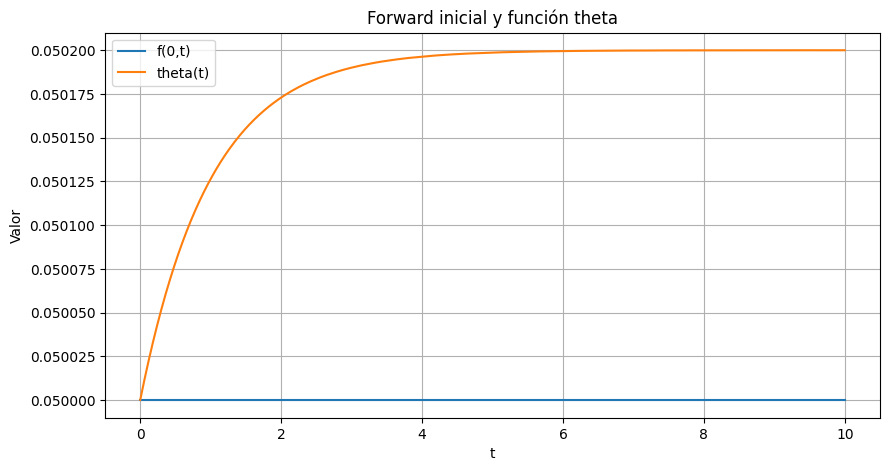

In [16]:
t_grid = np.linspace(0.001, 10, 500)

f_values = np.array([f0T(t) for t in t_grid])
theta_values = np.array([theta(t) for t in t_grid])

plt.figure(figsize=(10, 5))
plt.plot(t_grid, f_values, label="f(0,t)")
plt.plot(t_grid, theta_values, label="theta(t)")
plt.xlabel("t")
plt.ylabel("Valor")
plt.title("Forward inicial y función theta")
plt.grid(True)
plt.legend()
plt.show()

#### Simulación del tipo corto

Usando Euler:

$ r_{t+\Delta t} = r_t + \lambda(\theta(t)-r_t)\Delta t + \eta \sqrt{\Delta t} Z $

donde $ Z \sim N(0,1)$.

Donde
- $ r_t $: valor actual del tipo corto;
- $ \lambda(\theta(t)-r_t)\Delta t $: tendencia de reversión hacia la media temporal;
- $ \eta \sqrt{\Delta t} Z $: componente aleatoria.

In [20]:
def GeneratePathsHWEuler(NoOfPaths, NoOfSteps, T, P0T, lambd, eta):
    """
    Simula trayectorias de r_t bajo el modelo de Hull–White
    mediante Euler.

    Parámetros
    ----------
    NoOfPaths : Número de trayectorias Monte Carlo.
    NoOfSteps : Número de pasos temporales.
    T :         Horizonte temporal.
    P0T :       Curva inicial de descuento P(0,T).
    lambd :     Velocidad de reversión a la media.
    eta :       Volatilidad del tipo corto.

    Devuelve trayectorias simuladas del tipo corto para cada t
    """

    ## 1. DERIVADAS NUMÉRICAS SOBRE LA CURVA
    
    # Paso pequeño SOLO para derivar la curva P(0,T)
    dt_diff = 1e-4

    # Forward instantáneo inicial:
    # f(0,t) = - d/dt log P(0,t)
    f0T = lambda t: -(np.log(P0T(t + dt_diff)) - np.log(P0T(t - dt_diff))) / (2 * dt_diff)

    # Tipo corto inicial: en t ~ 0
    r0 = f0T(1e-5)

    # Función theta(t), para calcular P(0,T)
    theta = lambda t: (
        1.0 / lambd * (f0T(t + dt_diff) - f0T(t - dt_diff)) / (2.0 * dt_diff)
        + f0T(t)
        + eta * eta / (2.0 * lambd * lambd) * (1.0 - np.exp(-2.0 * lambd * t))
    )

    # Variables normales estándar
    Z = np.random.normal(0.0, 1.0, [NoOfPaths, NoOfSteps])

    # Browniano 
    W = np.zeros([NoOfPaths, NoOfSteps + 1])

    # Trayectorias del tipo corto
    R = np.zeros([NoOfPaths, NoOfSteps + 1])
    R[:, 0] = r0

    # Malla temporal
    time = np.zeros([NoOfSteps + 1])

    dt = T / float(NoOfSteps)

    for i in range(NoOfSteps):

        # Normalización
        if NoOfPaths > 1:
            Z[:, i] = (Z[:, i] - np.mean(Z[:, i])) / np.std(Z[:, i])

        # Incremento del movimiento browniano
        W[:, i + 1] = W[:, i] + np.sqrt(dt) * Z[:, i]

        #Euler para el short rate:
        R[:, i + 1] = (
            R[:, i]
            + lambd * (theta(time[i]) - R[:, i]) * dt
            + eta * (W[:, i + 1] - W[:, i])
        )
        
        time[i + 1] = time[i] + dt

    paths = {"time": time, "R": R}
    return paths

#### Análisis de parámetros

Vamos a ver el efecto de:
- $ \lambda $: velocidad de reversión;
- $ \eta $: volatilidad del tipo corto.

lo que esperaríamos sería
- a mayor $ \lambda $, más fuerte es la reversión a la media;
- a mayor $ \eta $, mayor dispersión de las trayectorias.

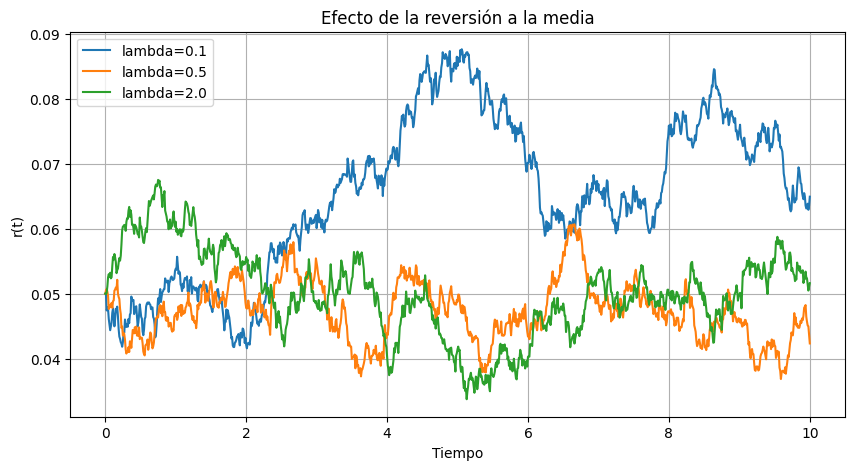

In [22]:
# Efecto de lambda
plt.figure(figsize=(10, 5))
for lambd_test in [0.1, 0.5, 2.0]:
    paths = GeneratePathsHWEuler(
        NoOfPaths=1,
        NoOfSteps=1000,
        T=10.0,
        P0T=P0T,
        lambd=lambd_test,
        eta=0.01
    )
    plt.plot(paths["time"], paths["R"][0], label=f"lambda={lambd_test}")

plt.xlabel("Tiempo")
plt.ylabel("r(t)")
plt.title("Efecto de la reversión a la media")
plt.grid(True)
plt.legend()
plt.show()

Se observa que el parámetro λ controla la velocidad de reversión a la media del tipo corto. Para valores bajos de λ, el proceso presenta 
mayor persistencia y puede desviarse significativamente del nivel medio. 
En cambio, para valores altos, el tipo de interés se mantiene más próximo a la media temporal θ(t).

En este caso, al considerar una curva inicial plana, la función θ(t) es aproximadamente constante, por lo que el proceso parece 
revertir hacia un nivel fijo cercano al 5%. Sin embargo, en el caso general, θ(t) depende de la estructura temporal inicial de tipos de interés.

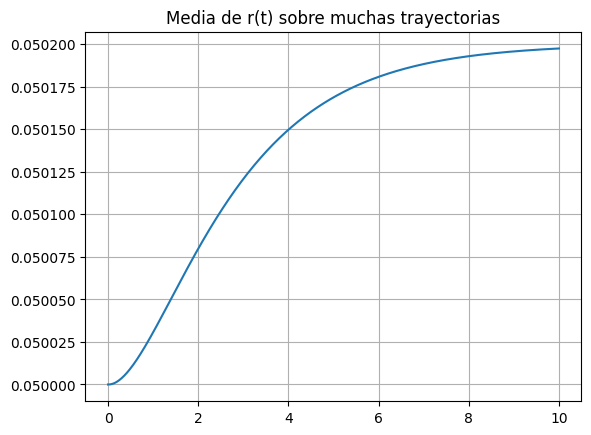

In [27]:
NoOfPaths = 1000

paths = GeneratePathsHWEuler(
    NoOfPaths,
    NoOfSteps=500,
    T=10,
    P0T=P0T,
    lambd=0.5,
    eta=0.01
)

mean_path = np.mean(paths["R"], axis=0)

plt.plot(paths["time"], mean_path)
plt.title("Media de r(t) sobre muchas trayectorias")
plt.grid()

La media empírica de las trayectorias del tipo corto muestra un ligero sesgo respecto al valor teórico esperado, que en este caso es constante e igual al forward inicial. Este comportamiento se debe a la discretización temporal mediante Euler y a la aproximación numérica de θ(t). No obstante, el error observado es pequeño y decrece al refinar la malla temporal, lo que confirma la consistencia del método de simulación.

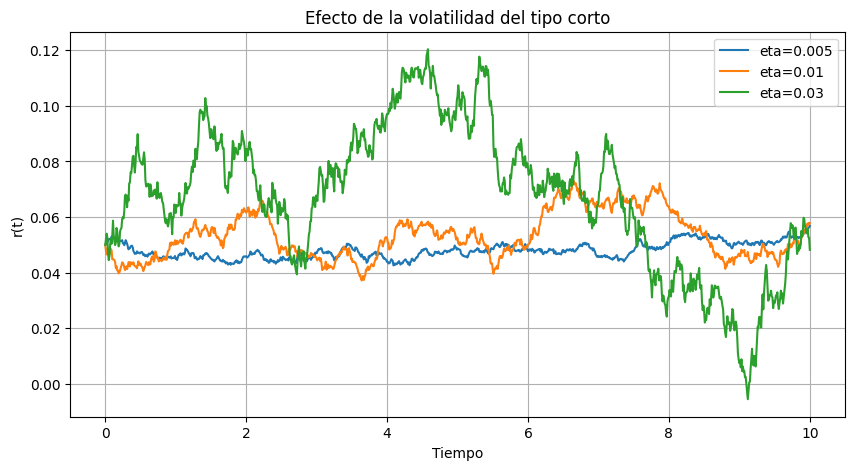

In [24]:
# Efecto de eta
plt.figure(figsize=(10, 5))
for eta_test in [0.005, 0.01, 0.03]:
    paths = GeneratePathsHWEuler(
        NoOfPaths=1,
        NoOfSteps=1000,
        T=10.0,
        P0T=P0T,
        lambd=0.5,
        eta=eta_test
    )
    plt.plot(paths["time"], paths["R"][0], label=f"eta={eta_test}")

plt.xlabel("Tiempo")
plt.ylabel("r(t)")
plt.title("Efecto de la volatilidad del tipo corto")
plt.grid(True)
plt.legend()
plt.show()

El parámetro η controla la volatilidad del tipo corto en el modelo de Hull–White. A medida que η aumenta, las trayectorias presentan una mayor dispersión alrededor de la media temporal θ(t). Se observa que el modelo permite valores negativos del tipo de interés. Este aspecto puede ser realista en ciertos entornos de mercado, aunque constituye una limitación estructural del modelo desde un punto de vista económico.